# Project WebScrubbing and EDA analysis
    Topic : New vacancies in Naukri.com based on the Data Keyword. 

#AI
# In the project, I wanted to know, if the user will type *Data on the keyword on Naukri then how many jobs will display for the people.

The project focus on the Naukri Web Notification, which notification display by the outside companies recruiters and using web scrapping I am collecting all data which are related to the Job content, Payable amount, Experience etc..
With the help of Python pandas & Numpy concept, we will create the DataFrame  and save in the form of Excel. Then we will apply some Data cleansing, Engineering Featuring concept and EDA analysis.
Aim: my aim to write this code, because, I want to know which city hiring the maximum count of people for which profile with key skill.



# Python libraries used:
    1. requests: This is used to extract the HTML code from the given URL.
    2. BeautifulSoup: This is used to format and read the HTML content.
    3. re (Regular Expression)
    4. Numpy, Pandas, matplotlib, Seaborn etc...(With the help of we will create the Clean dataFrame and Analyse like Descriptive and Daignostic Analysis)

# Import all relavent libraries

In [2]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager

In [4]:
!pip install selenium
!pip install webdriver_manager

  Using cached selenium-3.141.0-py2.py3-none-any.whl (904 kB)


In [3]:
driver = webdriver.Chrome(ChromeDriverManager().install())



====== WebDriver manager ======
Current google-chrome version is 90.0.4430
Get LATEST driver version for 90.0.4430
Get LATEST driver version for 90.0.4430
Trying to download new driver from https://chromedriver.storage.googleapis.com/90.0.4430.24/chromedriver_win32.zip
Driver has been saved in cache [C:\Users\RAJAT SAHU\.wdm\drivers\chromedriver\win32\90.0.4430.24]


# Web scraping
    Content : Web scraping, web harvesting, or web data extraction is data scraping used for extracting data from websites. 
    

In [10]:
j = []
c = []
Ex = []
Rupees =[]
Location =[]
Jt =[]
LS= []
for i in range(1,12):
    URL = "https://www.naukri.com/data-jobs-"+str(i)+"?k=data"
    soup = BeautifulSoup(driver.page_source,'html5lib')
    #job Title
    jobtitle= soup.find_all('article',attrs={'class':'jobTuple bgWhite br4 mb-8'})
    for jb in jobtitle:
        j.append(jb.find('a',attrs={'class':'title fw500 ellipsis'}).text)
    #comapny
    company = soup.find_all('div',{'class':'mt-7 companyInfo subheading lh16'})
    for cm in company:
        c.append((cm.find('a',attrs={'class':'subTitle ellipsis fleft'}).text))
    #Exprience
    ex = soup.find_all('ul',{'class':'mt-7'})
    for e in ex:
        Ex.append(e.find('span',attrs={'class':'ellipsis fleft fs12 lh16'}).text)
    #JOB tile
    jb = soup.find_all('ul',{'class':'tags has-description'})
    for e in jb:
        cl = e.find_all('li',{'fleft fs12 grey-text lh16 dot'})
        k1=[]
        for i in range(len(cl)):
            k1.append(cl[i].text)
        Jt.append(k1)
    #Rupees
    rs = soup.find_all('ul',{'class':'mt-7'})
    for e in rs:
        Rupees.append(e.find('li',attrs={'class':'fleft grey-text br2 placeHolderLi salary'}).text)
    #Location
    rs = soup.find_all('ul',{'class':'mt-7'})
    for e in rs:
        Location.append(e.find('li',attrs={'class':'fleft grey-text br2 placeHolderLi location'}).text)
for i in range(1,12):
    URL = "https://www.naukri.com/data-jobs-"+str(i)+"?k=data"
    soup = BeautifulSoup(driver.page_source,'html5lib')
    ##last update
    lsupdate = soup.find_all('article',attrs={'class':'jobTuple bgWhite br4 mb-8'})
    for i in lsupdate:
        ls = i.find_all('span',attrs={'class':'fleft fw500'})
        a =[]
        for j1 in range(len(ls)):
            a.append(ls[j1].text)
        LS.append(a)

# Create DataFrame
    All Web Screping Data stored in the Lists, code i have written in the last cell, and now we want to Analyse so we have to store these all list data in the DataFrame. 

In [11]:
df = pd.DataFrame({"JobContent":j,"Comapny":c,"Exprience":Ex,"JobTitle":Jt,'Location':Location,"LastUpdate":LS,"Payment":Rupees})
df

,JobContent,Comapny,Exprience,JobTitle,Location,LastUpdate,Payment
0,Data Engineer,Bajaj Finserv,0-3 Yrs,"[MS SQL, Data modeling, Schema, SSIS, Business...",Pune,[7 Days Ago],Not disclosed
1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,0-5 Yrs,"[bpo, self employed, cce, Non Voice Process, c...","Indore, Hyderabad/Secunderabad, Bangalore/Beng...","[HOT JOB, 8 Days Ago]","2,75,000 - 7,00,000 PA."
2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,0-3 Yrs,"[BPO, data entry, Customer Service, Word, MNC,...",Pune,"[HOT JOB, 5 Days Ago]","1,25,000 - 3,25,000 PA."
3,Data Engineer,Quality Engineering Software Technologies Pvt...,0-2 Yrs,"[IT Skills, Python, Cloud, Big Data, AWS, Tabl...",Bangalore/Bengaluru,[13 Days Ago],Not disclosed
4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,0-1 Yrs,"[data analysis, SQL DBs, Analytical, Big Data ...",Bangalore/Bengaluru,"[HOT JOB, 10 Days Ago]",Not disclosed
...,...,...,...,...,...,...,...
215,Data Entry Operator,BRIGADE ENTERPRISES LIMITED,0-3 Yrs,"[SAP, Data Entry Operation]",Chennai(Perungudi),"[HOT JOB, 3 Days Ago]","2,00,000 - 2,50,000 PA."
216,Data Entry Operator,TOmetal.com,0-3 Yrs,"[Customer Support, Data Entry Operation]",Mumbai(Powai),"[HOT JOB, 5 Days Ago]","1,00,000 - 3,00,000 PA."
217,Data Entry Operator,SREE BALAJI ENTERPRISES,0-5 Yrs,"[Entry, Typing, Data, Data Operations, English...",Chennai(Madhavaram Milk Colony +9),"[HOT JOB, 6 Days Ago]","1,00,000 - 1,75,000 PA."
218,Data Entry Operator,Source Digital,0-1 Yrs,"[Excel, MS Office, Data Entry Operation]",Chennai,"[HOT JOB, 6 Days Ago]","1,25,000 - 1,75,000 PA."


# DataFrame store in the CSV file

In [13]:
df.to_csv(r'C:\Users\RAJAT SAHU\Data_Science\NaukriData.csv')

# Read Data from the CSV file

In [149]:
df = pd.read_csv(r'C:\Users\RAJAT SAHU\Data_Science\NaukriData.csv')

# Top 5 row of the DataFrame

In [150]:
df.head()

,Unnamed: 0,JobContent,Comapny,Exprience,JobTitle,Location,LastUpdate,Payment
0,0,Data Engineer,Bajaj Finserv,0-3 Yrs,"['MS SQL', 'Data modeling', 'Schema', 'SSIS', ...",Pune,['7 Days Ago'],Not disclosed
1,1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,0-5 Yrs,"['bpo', 'self employed', 'cce', 'Non Voice Pro...","Indore, Hyderabad/Secunderabad, Bangalore/Beng...","['HOT JOB', '8 Days Ago']","2,75,000 - 7,00,000 PA."
2,2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,0-3 Yrs,"['BPO', 'data entry', 'Customer Service', 'Wor...",Pune,"['HOT JOB', '5 Days Ago']","1,25,000 - 3,25,000 PA."
3,3,Data Engineer,Quality Engineering Software Technologies Pvt...,0-2 Yrs,"['IT Skills', 'Python', 'Cloud', 'Big Data', '...",Bangalore/Bengaluru,['13 Days Ago'],Not disclosed
4,4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,0-1 Yrs,"['data analysis', 'SQL DBs', 'Analytical', 'Bi...",Bangalore/Bengaluru,"['HOT JOB', '10 Days Ago']",Not disclosed


# Last 5 row of the DataFrame

In [151]:
df.tail()

,Unnamed: 0,JobContent,Comapny,Exprience,JobTitle,Location,LastUpdate,Payment
215,215,Data Entry Operator,BRIGADE ENTERPRISES LIMITED,0-3 Yrs,"['SAP', 'Data Entry Operation']",Chennai(Perungudi),"['HOT JOB', '3 Days Ago']","2,00,000 - 2,50,000 PA."
216,216,Data Entry Operator,TOmetal.com,0-3 Yrs,"['Customer Support', 'Data Entry Operation']",Mumbai(Powai),"['HOT JOB', '5 Days Ago']","1,00,000 - 3,00,000 PA."
217,217,Data Entry Operator,SREE BALAJI ENTERPRISES,0-5 Yrs,"['Entry', 'Typing', 'Data', 'Data Operations',...",Chennai(Madhavaram Milk Colony +9),"['HOT JOB', '6 Days Ago']","1,00,000 - 1,75,000 PA."
218,218,Data Entry Operator,Source Digital,0-1 Yrs,"['Excel', 'MS Office', 'Data Entry Operation']",Chennai,"['HOT JOB', '6 Days Ago']","1,25,000 - 1,75,000 PA."
219,219,Data Entry Operator,G.C.C biotech india pvt ltd,0-1 Yrs,"['Typing', 'English Proficiency', 'Data Entry'...",Kolkata,"['HOT JOB', '7 Days Ago']","80,000 - 1,25,000 PA."


### DataFrame Read for complete understanding

In [152]:
print(len(df.JobContent),len(df.Comapny),len(df.Exprience),len(df.JobTitle),len(df.Location),len(df.LastUpdate),len(df.Payment))

220 220 220 220 220 220 220


In [153]:
#shape of the Data
df.shape

(220, 8)

In [154]:
#unique Columns in the DataFrame
df.columns

Index(['Unnamed: 0', 'JobContent', 'Comapny', 'Exprience', 'JobTitle',
       'Location', 'LastUpdate', 'Payment'],
      dtype='object')

In [155]:
#Remove Unwanted Column
df.drop('Unnamed: 0',axis=1,inplace=True)

In [156]:
df.describe(include='all')

,JobContent,Comapny,Exprience,JobTitle,Location,LastUpdate,Payment
count,220,220,220,220,220,220,220
unique,14,19,4,20,15,12,12
top,Data Entry Operator,RANDSTAD INDIA PVT LTD,0-3 Yrs,"['Excel', 'VLOOKUP', 'Data Analysis', 'Data An...",Bangalore/Bengaluru,"['HOT JOB', '1 Day Ago']",Not disclosed
freq,55,22,77,11,44,33,77


In [157]:
#No null value found in the columns
df.isnull().sum()

JobContent    0
Comapny       0
Exprience     0
JobTitle      0
Location      0
LastUpdate    0
Payment       0
dtype: int64

In [158]:
df.dtypes


JobContent    object
Comapny       object
Exprience     object
JobTitle      object
Location      object
LastUpdate    object
Payment       object
dtype: object

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   JobContent  220 non-null    object
 1   Comapny     220 non-null    object
 2   Exprience   220 non-null    object
 3   JobTitle    220 non-null    object
 4   Location    220 non-null    object
 5   LastUpdate  220 non-null    object
 6   Payment     220 non-null    object
dtypes: object(7)
memory usage: 12.2+ KB


# Observation:
    There is no null value and all columns are objectionable data type (if necessary, we will change to engineering Featuring Concept)

# Data Munging & Engineering Featuring
    content: The next phase of a project involves a process called “data munging.” It is often the case where the data imported into the
                Python environment is inconvenient or incompatible with machine learning algorithms, so with data munging (also known as data transformation) the data can be massaged into a more hospitable form. Data munging cannot be taken lightly as many times it can consume up to 80% of the entire machine learning project. The amount of time needed for a particular project depends on the health of the data: how clean, how complete, how many missing elements, etc.

# Step 1st:
    data cleaning and Observations

#### Extract from the JobContent column actual job Name or role 

In [160]:
#First column : JobContent
df['JobName'] = df['JobContent'].apply(lambda x:re.compile('\w+\s\w+').search(x).group())

In [161]:
df.JobName.unique()

array(['Data Engineer', 'DATA Entry', 'Computer Operator', 'Big Data',
       'NTT DATA', 'Hiring Data', 'Data Entry', 'Computer Data',
       'Data Analyst', 'Hiring Candidates', 'Data Scientist',
       'Data Labelling'], dtype=object)

In [162]:
df.JobName.value_counts()

Data Entry           66
Data Engineer        33
Computer Data        22
Computer Operator    11
Big Data             11
Data Labelling       11
NTT DATA             11
Data Scientist       11
Hiring Candidates    11
DATA Entry           11
Hiring Data          11
Data Analyst         11
Name: JobName, dtype: int64

In [163]:
#Categorical Data - means, data should be store in the *Object* form.
df.JobName.dtypes

dtype('O')

# Observation:
    Accoring to these Job Name Column, we are getting the valuable data means when persons will type the Keyword on the Naukri the they wilt get the Maximun Percentage of the job in ***Data Entry 

In [164]:
#### Second Column : Comapny
df.Comapny.value_counts()

RANDSTAD INDIA PVT LTD                                                                             22
BRADY  MORRIS ENGINEERING COMPANY LIMITED                                                          11
Mac Tech Solutions                                                                                 11
Inflexion Analytix Private Limited                                                                 11
BRIGADE ENTERPRISES LIMITED                                                                        11
Computer Operator/data Entry/bpo                                                                   11
Dr Lal PathLabs                                                                                    11
TOmetal.com                                                                                        11
G.C.C biotech india pvt ltd                                                                        11
Fragma Data systems Pvt. Ltd.                                                     

# Observation:
    With this data we are getting the best results, the company Randstad is hiring a lot of people

In [165]:
#Same in the form Percentages
df.Comapny.value_counts(normalize=True)

RANDSTAD INDIA PVT LTD                                                                             0.10
BRADY  MORRIS ENGINEERING COMPANY LIMITED                                                          0.05
Mac Tech Solutions                                                                                 0.05
Inflexion Analytix Private Limited                                                                 0.05
BRIGADE ENTERPRISES LIMITED                                                                        0.05
Computer Operator/data Entry/bpo                                                                   0.05
Dr Lal PathLabs                                                                                    0.05
TOmetal.com                                                                                        0.05
G.C.C biotech india pvt ltd                                                                        0.05
Fragma Data systems Pvt. Ltd.                                   

# Observation:
    10% of the company not showing the company name, maybe it is a fake vacancies on the Naukri web.

In [166]:
#3rd Column : Exprience
df.Exprience.head()

0    0-3 Yrs
1    0-5 Yrs
2    0-3 Yrs
3    0-2 Yrs
4    0-1 Yrs
Name: Exprience, dtype: object

In [167]:
#Neumerical Data - means, data should be store in the *int* form.
df.Exprience.dtypes

#change *object to *int


dtype('O')

# Observation:
    In the Experience column, the values ​​are as Maximum and Minimum Experience. We will not be able to do any aggregation in a single column. So now we have to separate each other into 2 different columns like MinYear and MaxYear.

In [168]:
# Replace Yrs
df['Exprience'] = df.Exprience.str.replace('[a-zA-Z]','')

In [169]:
#Create New columns in the same DataFrame
df['MinExpriece']= df.Exprience.str[0]
df['MaxExpriece'] = df.Exprience.str[2]

In [170]:
df[['MinExpriece','MaxExpriece']].head(5)

,MinExpriece,MaxExpriece
0,0,3
1,0,5
2,0,3
3,0,2
4,0,1


In [171]:
df[['MinExpriece','MaxExpriece']].dtypes

MinExpriece    object
MaxExpriece    object
dtype: object

In [172]:
#we need to change with *object to *int.
df.MinExpriece=df.MinExpriece.astype('int')
df.MaxExpriece=df.MaxExpriece.astype('int')

In [173]:
#changed types of the columns
print(df.MinExpriece.dtypes,df.MaxExpriece.dtypes)

int32 int32


In [174]:
df.MinExpriece.value_counts()

0    220
Name: MinExpriece, dtype: int64

In [175]:
#value count in the Percentage
df.MaxExpriece.value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

3    35.0%
1    30.0%
5    20.0%
2    15.0%
Name: MaxExpriece, dtype: object

In [176]:
df.drop('Exprience',axis=1,inplace=True)

# Observation:
    35% of companies hire the Pepole, they should have 3 Year of Exprience and 30% of companies hire people should have a 1 year exprience.

In [180]:
#Third column : JobTitle
df[['JobSkill0','JobSkill1','JobSkill2','JobSkill3','JobSkill4','JobSkill5','JobSkill6','JobSkill7']] = df.JobTitle.str.split(',',expand=True)

In [181]:
df[['JobSkill0','JobSkill1','JobSkill2','JobSkill3','JobSkill4','JobSkill5','JobSkill6','JobSkill7']].head(2

,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7
0,['MS SQL','Data modeling','Schema','SSIS','Business solutions','Cosmos','Data warehousing','SQL']
1,['bpo','self employed','cce','Non Voice Process','computer operator','Computer Operating','customer care','Non Voice']


In [182]:
for i in range(8):
    df['JobSkill'+str(i)+'']= df['JobSkill'+str(i)+''].str.replace("[","")
    df['JobSkill'+str(i)+'']= df['JobSkill'+str(i)+''].str.replace("]","")
    df['JobSkill'+str(i)+'']= df['JobSkill'+str(i)+''].str.replace("'","")

In [183]:
df[['JobSkill0','JobSkill1','JobSkill2','JobSkill3','JobSkill4','JobSkill5','JobSkill6','JobSkill7']].head(2)

,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7
0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL
1,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice


In [184]:
#Forth Column : Location
df[['Location0','Location1','Location2','Location3','Location4','Location5']] = df.Location.str.split(',',expand=True)

In [185]:
df[['Location0','Location1','Location2','Location3','Location4','Location5']]

,Location0,Location1,Location2,Location3,Location4,Location5
0,Pune,None,None,None,None,None
1,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,None,None,None
2,Pune,None,None,None,None,None
3,Bangalore/Bengaluru,None,None,None,None,None
4,Bangalore/Bengaluru,None,None,None,None,None
...,...,...,...,...,...,...
215,Chennai(Perungudi),None,None,None,None,None
216,Mumbai(Powai),None,None,None,None,None
217,Chennai(Madhavaram Milk Colony +9),None,None,None,None,None
218,Chennai,None,None,None,None,None


In [186]:
df['Location0'].value_counts()

Bangalore/Bengaluru                   44
Pune                                  22
Mumbai                                22
Chennai                               22
Bangalore/Bengaluru(Marathahalli)     11
Chennai(Perungudi)                    11
Navi Mumbai                           11
Indore                                11
Thane                                 11
Mumbai(Powai)                         11
Ahmedabad                             11
Kolkata                               11
Pune(Pimpri Vallabhnagar +1)          11
Chennai(Madhavaram Milk Colony +9)    11
Name: Location0, dtype: int64

In [116]:
df['Location1'].value_counts()

 Hyderabad/Secunderabad    33
 Navi Mumbai               11
Name: Location1, dtype: int64

In [118]:
df['Location2'].value_counts()

 Pune                   22
 Bangalore/Bengaluru    11
Name: Location2, dtype: int64

In [119]:
df['Location3'].value_counts()

 Chennai             11
 Gurgaon/Gurugram    11
Name: Location3, dtype: int64

In [120]:
df['Location4'].value_counts()

 Chennai                11
 Bangalore/Bengaluru    11
Name: Location4, dtype: int64

In [121]:
df['Location5'].value_counts()

 Bangalore/Bengaluru    11
 Delhi / NCR            11
Name: Location5, dtype: int64

In [209]:
df.drop('Location',axis=1,inplace=True)

In [139]:
#df['Location0'] = df['Location0'].apply(lambda x:re.compile('\(\w+').search(x))

In [190]:
df.drop('JobTitle',axis=1,inplace=True)

In [191]:
df.head(3)

,JobContent,Comapny,Location,LastUpdate,Payment,JobName,MinExpriece,MaxExpriece,JobSkill0,JobSkill1,...,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4,Location5
0,Data Engineer,Bajaj Finserv,Pune,['7 Days Ago'],Not disclosed,Data Engineer,0,3,MS SQL,Data modeling,...,Business solutions,Cosmos,Data warehousing,SQL,Pune,None,None,None,None,None
1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,"Indore, Hyderabad/Secunderabad, Bangalore/Beng...","['HOT JOB', '8 Days Ago']","2,75,000 - 7,00,000 PA.",DATA Entry,0,5,bpo,self employed,...,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,None,None,None
2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,Pune,"['HOT JOB', '5 Days Ago']","1,25,000 - 3,25,000 PA.",Computer Operator,0,3,BPO,data entry,...,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,None,None,None,None,None


In [198]:
#Forth Column
df['LastUpdate']

0                  ['7 Days Ago']
1       ['HOT JOB', '8 Days Ago']
2       ['HOT JOB', '5 Days Ago']
3                 ['13 Days Ago']
4      ['HOT JOB', '10 Days Ago']
                  ...            
215     ['HOT JOB', '3 Days Ago']
216     ['HOT JOB', '5 Days Ago']
217     ['HOT JOB', '6 Days Ago']
218     ['HOT JOB', '6 Days Ago']
219     ['HOT JOB', '7 Days Ago']
Name: LastUpdate, Length: 220, dtype: object

In [202]:
df['LastUpdate'] = df['LastUpdate'].str.split(',',expand=True)[0]

In [205]:
df['LastUpdate']=df['LastUpdate'].str.replace("[","")
df['LastUpdate']=df['LastUpdate'].str.replace("]","")
df['LastUpdate']=df['LastUpdate'].str.replace("'","")

In [206]:
df['LastUpdate']

0       7 Days Ago
1          HOT JOB
2          HOT JOB
3      13 Days Ago
4          HOT JOB
          ...     
215        HOT JOB
216        HOT JOB
217        HOT JOB
218        HOT JOB
219        HOT JOB
Name: LastUpdate, Length: 220, dtype: object

In [207]:
df['LastUpdate'].value_counts()

HOT JOB        187
13 Days Ago     11
PREFERRED       11
7 Days Ago      11
Name: LastUpdate, dtype: int64

In [210]:
df.head()

,JobContent,Comapny,LastUpdate,Payment,JobName,MinExpriece,MaxExpriece,JobSkill0,JobSkill1,JobSkill2,...,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4,Location5
0,Data Engineer,Bajaj Finserv,7 Days Ago,Not disclosed,Data Engineer,0,3,MS SQL,Data modeling,Schema,...,Business solutions,Cosmos,Data warehousing,SQL,Pune,None,None,None,None,None
1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,"2,75,000 - 7,00,000 PA.",DATA Entry,0,5,bpo,self employed,cce,...,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,None,None,None
2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,"1,25,000 - 3,25,000 PA.",Computer Operator,0,3,BPO,data entry,Customer Service,...,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,None,None,None,None,None
3,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,Not disclosed,Data Engineer,0,2,IT Skills,Python,Cloud,...,AWS,Tableau,Power BI,Computer science,Bangalore/Bengaluru,None,None,None,None,None
4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,Not disclosed,Big Data,0,1,data analysis,SQL DBs,Analytical,...,Spark SQL,Pyspark,Dataframe core,IT Skills,Bangalore/Bengaluru,None,None,None,None,None


In [211]:
#Fifth Column : Payment
df['Payment']

0                Not disclosed
1      2,75,000 - 7,00,000 PA.
2      1,25,000 - 3,25,000 PA.
3                Not disclosed
4                Not disclosed
                ...           
215    2,00,000 - 2,50,000 PA.
216    1,00,000 - 3,00,000 PA.
217    1,00,000 - 1,75,000 PA.
218    1,25,000 - 1,75,000 PA.
219      80,000 - 1,25,000 PA.
Name: Payment, Length: 220, dtype: object

In [212]:
df['Payment'] = df.Payment.str.replace('PA.','')
df['Payment'] = df.Payment.str.replace('.','')

In [214]:
df.Payment.value_counts()

Not disclosed           77
1,00,000 - 3,00,000     22
1,25,000 - 1,75,000     22
1,25,000 - 3,25,000     11
3,50,000 - 4,50,000     11
50,000 - 3,00,000       11
50,000 - 2,00,000       11
2,00,000 - 2,50,000     11
3,25,000 - 4,50,000     11
80,000 - 1,25,000       11
1,00,000 - 1,75,000     11
2,75,000 - 7,00,000     11
Name: Payment, dtype: int64

In [220]:
df['Payment']=df['Payment'].replace("Not disclosed","0-0")

In [222]:
df[['MinPay','MaxPay']]=df['Payment'].str.split('-',expand=True)

In [225]:
df.drop('Payment',axis=1,inplace=True)

In [233]:
df[['MinPay','MaxPay']].head()

,MinPay,MaxPay
0,0,0
1,"2,75,000","7,00,000"
2,"1,25,000","3,25,000"
3,0,0
4,0,0


In [237]:
df['MinPay']=df['MinPay'].str.replace(",","")
df['MaxPay']=df['MaxPay'].str.replace(",","")

In [238]:
df[['MinPay','MaxPay']].head()

,MinPay,MaxPay
0,0,0
1,275000,700000
2,125000,325000
3,0,0
4,0,0


In [243]:
df[['MinPay','MaxPay']]=df[['MinPay','MaxPay']].astype('int')

In [244]:
df[['MinPay','MaxPay']].dtypes

MinPay    int32
MaxPay    int32
dtype: object

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   JobContent   220 non-null    object
 1   Comapny      220 non-null    object
 2   LastUpdate   220 non-null    object
 3   JobName      220 non-null    object
 4   MinExpriece  220 non-null    int32 
 5   MaxExpriece  220 non-null    int32 
 6   JobSkill0    220 non-null    object
 7   JobSkill1    209 non-null    object
 8   JobSkill2    176 non-null    object
 9   JobSkill3    165 non-null    object
 10  JobSkill4    154 non-null    object
 11  JobSkill5    143 non-null    object
 12  JobSkill6    132 non-null    object
 13  JobSkill7    132 non-null    object
 14  Location0    220 non-null    object
 15  Location1    44 non-null     object
 16  Location2    33 non-null     object
 17  Location3    22 non-null     object
 18  Location4    22 non-null     object
 19  Location5    22 non-null     

In [246]:
df.head()

,JobContent,Comapny,LastUpdate,JobName,MinExpriece,MaxExpriece,JobSkill0,JobSkill1,JobSkill2,JobSkill3,...,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4,Location5,MinPay,MaxPay
0,Data Engineer,Bajaj Finserv,7 Days Ago,Data Engineer,0,3,MS SQL,Data modeling,Schema,SSIS,...,Data warehousing,SQL,Pune,None,None,None,None,None,0,0
1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,DATA Entry,0,5,bpo,self employed,cce,Non Voice Process,...,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,None,None,None,275000,700000
2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,Computer Operator,0,3,BPO,data entry,Customer Service,Word,...,Data Maintenance,Voice Process,Pune,None,None,None,None,None,125000,325000
3,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,Data Engineer,0,2,IT Skills,Python,Cloud,Big Data,...,Power BI,Computer science,Bangalore/Bengaluru,None,None,None,None,None,0,0
4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,Big Data,0,1,data analysis,SQL DBs,Analytical,Big Data programming,...,Dataframe core,IT Skills,Bangalore/Bengaluru,None,None,None,None,None,0,0


In [247]:
df.columns

Index(['JobContent', 'Comapny', 'LastUpdate', 'JobName', 'MinExpriece',
       'MaxExpriece', 'JobSkill0', 'JobSkill1', 'JobSkill2', 'JobSkill3',
       'JobSkill4', 'JobSkill5', 'JobSkill6', 'JobSkill7', 'Location0',
       'Location1', 'Location2', 'Location3', 'Location4', 'Location5',
       'MinPay', 'MaxPay'],
      dtype='object')

In [250]:
Data = df[['JobName','JobContent','Comapny','LastUpdate','MinExpriece','MaxExpriece','MinPay','MaxPay','JobSkill0','JobSkill1','JobSkill2','JobSkill3','JobSkill4','JobSkill5','JobSkill6','JobSkill7','Location0','Location1','Location2','Location3','Location4']]

In [251]:
Data.head()

,JobName,JobContent,Comapny,LastUpdate,MinExpriece,MaxExpriece,MinPay,MaxPay,JobSkill0,JobSkill1,...,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,...,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,None,None,None,None
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,...,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,None,None
2,Computer Operator,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,0,3,125000,325000,BPO,data entry,...,Word,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,None,None,None,None
3,Data Engineer,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,0,2,0,0,IT Skills,Python,...,Big Data,AWS,Tableau,Power BI,Computer science,Bangalore/Bengaluru,None,None,None,None
4,Big Data,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,0,1,0,0,data analysis,SQL DBs,...,Big Data programming,Spark SQL,Pyspark,Dataframe core,IT Skills,Bangalore/Bengaluru,None,None,None,None


In [252]:
Data.rename(columns={'MinExpriece':'MinExprience','MaxExpriece':'MaxExprience','Comapny':'company'},inplace=True)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:4296: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [256]:
Data.shape

(220, 21)

In [257]:
#Final DataFrame Shape and Now, i will work on it, for all Visual Analysis.
df.to_csv(r'C:\Users\RAJAT SAHU\Data_Science\ProjectData.csv')

# Exploratory Data Analysis
    Content: Exploratory Data Analysis, or EDA, is essentially a type of storytelling for statisticians. It allows us to uncover patterns and insights, often with visual methods, within data. EDA is often the first step of the data modelling process.

In [3]:
Data1 = pd.read_csv(r'C:\Users\RAJAT SAHU\Data_Science\ProjectData.csv')
Data1.head(5)

,Unnamed: 0,JobContent,Comapny,LastUpdate,JobName,MinExpriece,MaxExpriece,JobSkill0,JobSkill1,JobSkill2,...,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4,Location5,MinPay,MaxPay
0,0,Data Engineer,Bajaj Finserv,7 Days Ago,Data Engineer,0,3,MS SQL,Data modeling,Schema,...,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN,NaN,0,0
1,1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,DATA Entry,0,5,bpo,self employed,cce,...,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN,NaN,275000,700000
2,2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,Computer Operator,0,3,BPO,data entry,Customer Service,...,Data Maintenance,Voice Process,Pune,NaN,NaN,NaN,NaN,NaN,125000,325000
3,3,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,Data Engineer,0,2,IT Skills,Python,Cloud,...,Power BI,Computer science,Bangalore/Bengaluru,NaN,NaN,NaN,NaN,NaN,0,0
4,4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,Big Data,0,1,data analysis,SQL DBs,Analytical,...,Dataframe core,IT Skills,Bangalore/Bengaluru,NaN,NaN,NaN,NaN,NaN,0,0


In [5]:
pd.set_option("display.max_columns",None)
Data1.head()

,Unnamed: 0,JobContent,Comapny,LastUpdate,JobName,MinExpriece,MaxExpriece,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4,Location5,MinPay,MaxPay
0,0,Data Engineer,Bajaj Finserv,7 Days Ago,Data Engineer,0,3,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN,NaN,0,0
1,1,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,DATA Entry,0,5,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN,NaN,275000,700000
2,2,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,Computer Operator,0,3,BPO,data entry,Customer Service,Word,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,NaN,NaN,NaN,NaN,NaN,125000,325000
3,3,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,Data Engineer,0,2,IT Skills,Python,Cloud,Big Data,AWS,Tableau,Power BI,Computer science,Bangalore/Bengaluru,NaN,NaN,NaN,NaN,NaN,0,0
4,4,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,Big Data,0,1,data analysis,SQL DBs,Analytical,Big Data programming,Spark SQL,Pyspark,Dataframe core,IT Skills,Bangalore/Bengaluru,NaN,NaN,NaN,NaN,NaN,0,0


In [6]:
#Unique column in the data Frames and one is unwanted column which i have to delete : ***Unnamed: 0
Data1.columns

Index(['Unnamed: 0', 'JobContent', 'Comapny', 'LastUpdate', 'JobName',
       'MinExpriece', 'MaxExpriece', 'JobSkill0', 'JobSkill1', 'JobSkill2',
       'JobSkill3', 'JobSkill4', 'JobSkill5', 'JobSkill6', 'JobSkill7',
       'Location0', 'Location1', 'Location2', 'Location3', 'Location4',
       'Location5', 'MinPay', 'MaxPay'],
      dtype='object')

In [7]:
#Delete unwanted column
Data1.drop('Unnamed: 0',axis=1,inplace=True)

In [8]:
#final unique columns in DataFrames
Data1.columns

Index(['JobContent', 'Comapny', 'LastUpdate', 'JobName', 'MinExpriece',
       'MaxExpriece', 'JobSkill0', 'JobSkill1', 'JobSkill2', 'JobSkill3',
       'JobSkill4', 'JobSkill5', 'JobSkill6', 'JobSkill7', 'Location0',
       'Location1', 'Location2', 'Location3', 'Location4', 'Location5',
       'MinPay', 'MaxPay'],
      dtype='object')

In [9]:
#Rename the DataFrame columns
Data1.rename(columns={'MinExpriece':'MinExprience','MaxExpriece':'MaxExprience','Comapny':'company'},inplace=True)

In [10]:
# Arrange column location.
Data1 = Data1[['JobName','JobContent','company','LastUpdate','MinExprience','MaxExprience','MinPay','MaxPay','JobSkill0','JobSkill1','JobSkill2','JobSkill3','JobSkill4','JobSkill5','JobSkill6','JobSkill7','Location0','Location1','Location2','Location3','Location4']]

In [11]:
#final DataFrame with complete cleansing and Engineering Featuring concept.
Data1.head()

,JobName,JobContent,company,LastUpdate,MinExprience,MaxExprience,MinPay,MaxPay,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN
2,Computer Operator,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,0,3,125000,325000,BPO,data entry,Customer Service,Word,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,NaN,NaN,NaN,NaN
3,Data Engineer,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,0,2,0,0,IT Skills,Python,Cloud,Big Data,AWS,Tableau,Power BI,Computer science,Bangalore/Bengaluru,NaN,NaN,NaN,NaN
4,Big Data,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,0,1,0,0,data analysis,SQL DBs,Analytical,Big Data programming,Spark SQL,Pyspark,Dataframe core,IT Skills,Bangalore/Bengaluru,NaN,NaN,NaN,NaN


In [12]:
#Number of jobs count in the DataFrames
Data1.JobName.value_counts()

Data Entry           66
Data Engineer        33
Computer Data        22
Big Data             11
Hiring Data          11
Data Analyst         11
Hiring Candidates    11
DATA Entry           11
Data Labelling       11
Computer Operator    11
NTT DATA             11
Data Scientist       11
Name: JobName, dtype: int64

C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


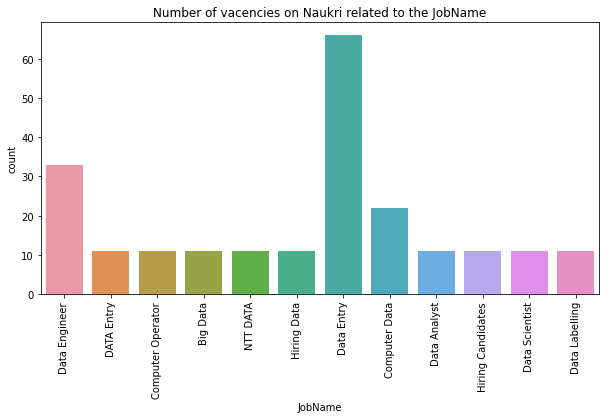

In [13]:
#Same result, we are plotting in the Bar plot using Seaborn concept
plt.figure(figsize=(10,5))
sns.countplot(Data1.JobName)
plt.xticks(rotation=90)
plt.title('Number of vacencies on Naukri related to the JobName')
plt.show()

# Observation:
    when i was collected from the Naukri Web: Max company hire for the Data Engineer, Data Entry and for other job smae status was similar.

C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


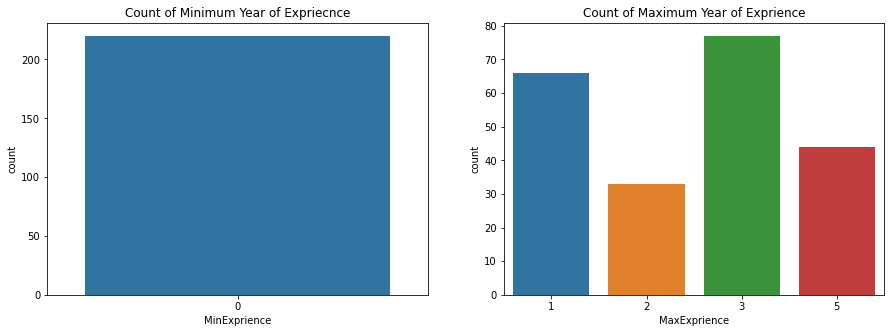

In [14]:
#plot graph between the count of the MinExp and MaxExp.
plt.figure(figsize=(15,5))
plt.subplot(121)
sns.countplot(Data1.MinExprience)
plt.title("Count of Minimum Year of Expriecnce")
plt.subplot(122)
sns.countplot(Data1.MaxExprience)
plt.title("Count of Maximum Year of Exprience")
plt.show()

# Observation:
    According to the data, which was collected before me last 4-5 days, at that time the maximum company underperformed the persons with 0-3 years of experience and 0-2 years of experience.
    Data Entry : 66
    Data Engineer : 33
    Computer Data : 22

In [15]:
#Pivot table : MaxExp and MinExp Count 
pd.pivot_table(data=Data1,index=['JobName'],aggfunc={'MinExprience':np.count_nonzero,'MaxExprience':np.count_nonzero})

,MaxExprience,MinExprience
JobName,,
Big Data,11,0
Computer Data,22,0
Computer Operator,11,0
DATA Entry,11,0
Data Analyst,11,0
Data Engineer,33,0
Data Entry,66,0
Data Labelling,11,0
Data Scientist,11,0


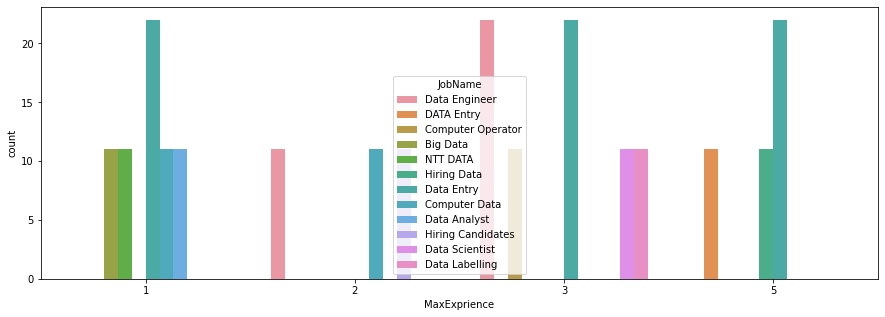

In [16]:
plt.figure(figsize=(15,5))
sns.countplot(data= Data1,x='MaxExprience',hue='JobName')
plt.title('')
plt.show()

# Observation:
    1 Year Exprience : Max number of vacancies in the NTT Data Job.
    2 Year Exprience : Number of Job type count are similar.
    3 Year Exprience : Max Number of vacancies notificaiton for the Data Engineer and Data Entry.
    4 Year Exprience : same as 3 Year Exprience, more Vacancies notification in the Data Entry.

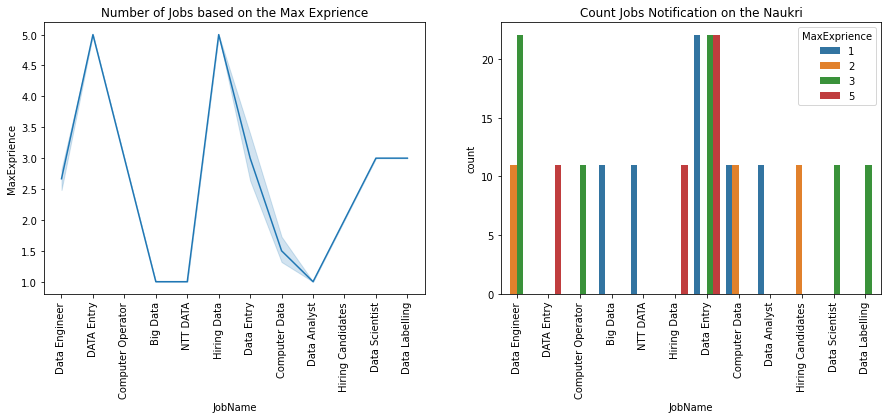

In [17]:
plt.figure(figsize=(15,5))
plt.subplot(121)
sns.lineplot(data=Data1,x='JobName',y='MaxExprience')
plt.xticks(rotation=90)
plt.title("Number of Jobs based on the Max Exprience")
plt.subplot(122)
sns.countplot(data=Data1,x='JobName',hue='MaxExprience')
plt.xticks(rotation=90)
plt.title("Count Jobs Notification on the Naukri")
plt.show()

# Observation:
    Note: Two Graph for understand different-2 secnerio
        1. Fig-1: For Data Entry, company want the higher exprience and Maximimum count of notification related the Data-Entry(Fig-2)
    .

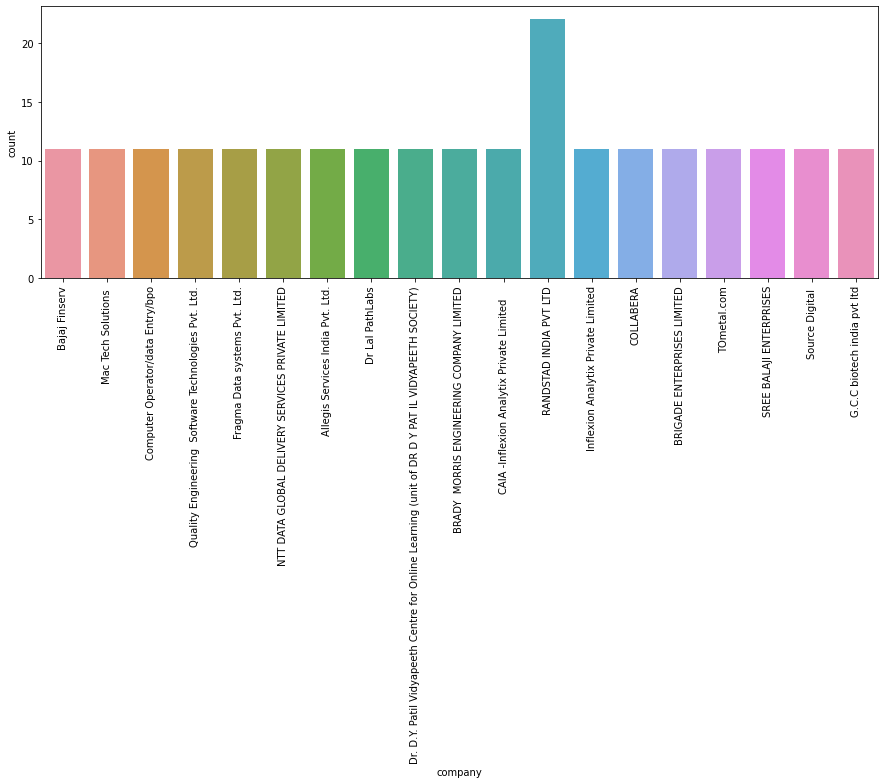

In [18]:
plt.figure(figsize=(15,5))
sns.countplot(data=Data1,x='company')
plt.xticks(rotation=90)
plt.show()

In [19]:
Data1.head(2)

,JobName,JobContent,company,LastUpdate,MinExprience,MaxExprience,MinPay,MaxPay,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN


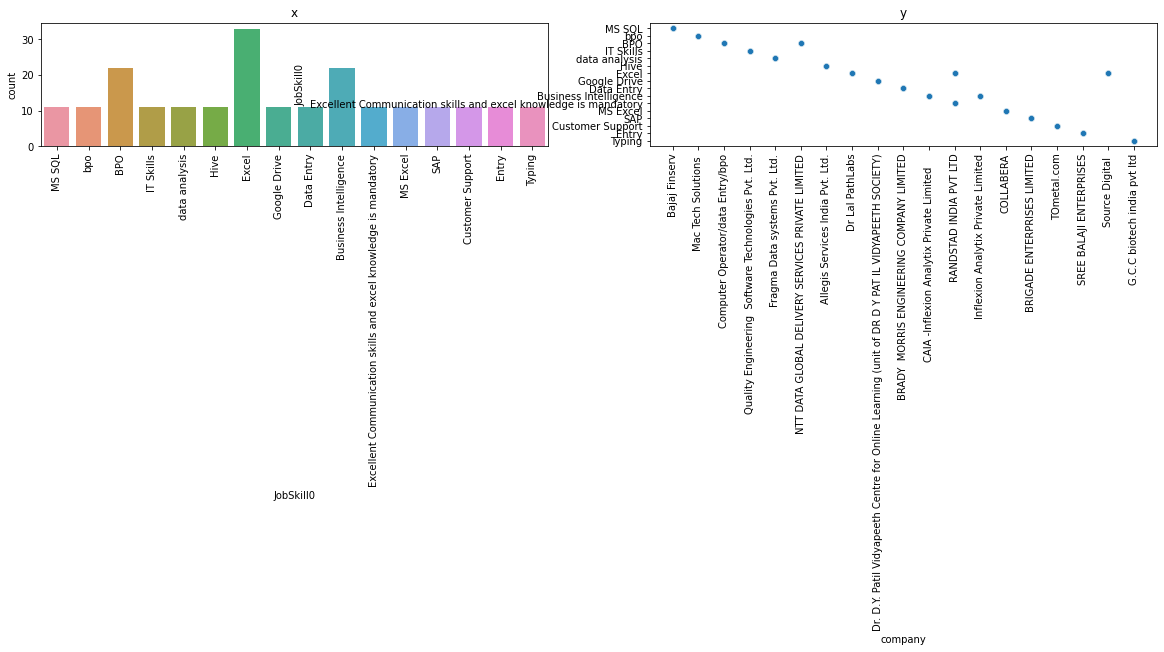

In [20]:
plt.figure(figsize=(20,5))
plt.subplot(221)
sns.countplot(data=Data1,x='JobSkill0')
plt.title("x")
plt.xticks(rotation=90)
plt.subplot(222)
sns.scatterplot(data=Data1,x='company',y='JobSkill0')
plt.title("y")
plt.xticks(rotation=90)
plt.show()

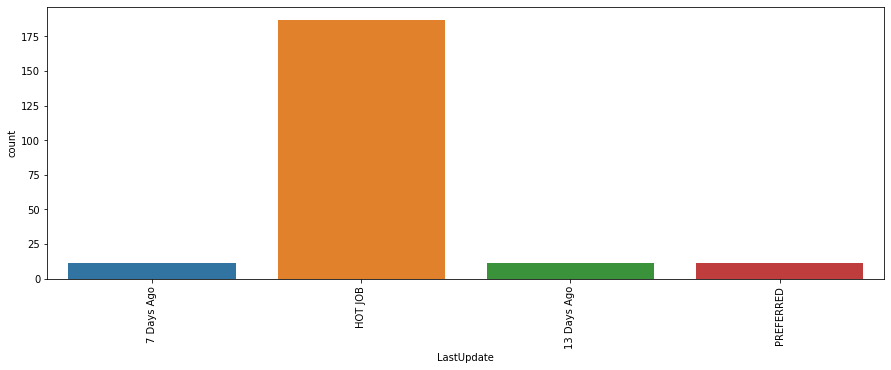

In [21]:
plt.figure(figsize=(15,5))
sns.countplot(data=Data1,x='LastUpdate')
plt.xticks(rotation=90)
plt.show()

In [22]:
Data1.groupby(['company'])['LastUpdate'].count()

company
Allegis Services India Pvt. Ltd.                                                                   11
BRADY  MORRIS ENGINEERING COMPANY LIMITED                                                          11
BRIGADE ENTERPRISES LIMITED                                                                        11
Bajaj Finserv                                                                                      11
CAIA -Inflexion Analytix Private Limited                                                           11
COLLABERA                                                                                          11
Computer Operator/data Entry/bpo                                                                   11
Dr Lal PathLabs                                                                                    11
Dr. D.Y. Patil Vidyapeeth Centre for Online Learning (unit of DR D Y PAT IL VIDYAPEETH SOCIETY)    11
Fragma Data systems Pvt. Ltd.                                             

# Observation:
    Now we have got more valuable data, means most of the vacancies Notification on Naukri for this company *RANDSTAD INDIA PVT LTD.

In [23]:
#summry structure between the company, jobName and MaxExprience
pv = pd.pivot_table(data=Data1,index=['company','JobName','MaxExprience'],aggfunc={'MinPay':np.mean,'MaxPay':np.mean})

In [24]:
pv1=pv.sort_values(by=['MaxExprience','MaxPay','MinPay'],ascending=False)
pv1

,,,MaxPay,MinPay
company,JobName,MaxExprience,,
Mac Tech Solutions,DATA Entry,5,700000,275000
Dr Lal PathLabs,Data Entry,5,200000,50000
SREE BALAJI ENTERPRISES,Data Entry,5,175000,100000
Allegis Services India Pvt. Ltd.,Hiring Data,5,0,0
Inflexion Analytix Private Limited,Data Scientist,3,450000,350000
CAIA -Inflexion Analytix Private Limited,Data Engineer,3,450000,325000
Computer Operator/data Entry/bpo,Computer Operator,3,325000,125000
TOmetal.com,Data Entry,3,300000,100000
BRIGADE ENTERPRISES LIMITED,Data Entry,3,250000,200000


<Figure size 1440x720 with 0 Axes>

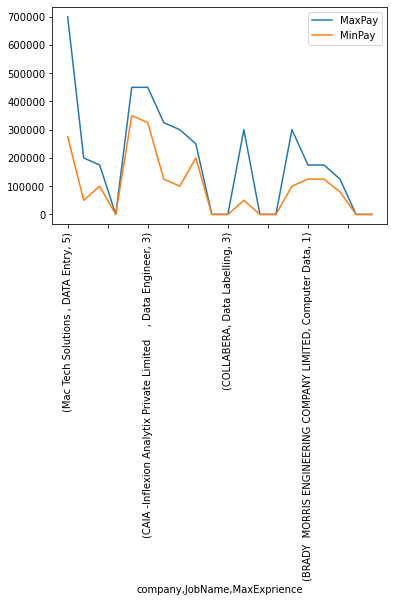

In [25]:
plt.figure(figsize=(20,10))
pv1.plot()
plt.xticks(rotation=90)
plt.show()

In [26]:
pv1.head(5)

,,,MaxPay,MinPay
company,JobName,MaxExprience,,
Mac Tech Solutions,DATA Entry,5,700000,275000
Dr Lal PathLabs,Data Entry,5,200000,50000
SREE BALAJI ENTERPRISES,Data Entry,5,175000,100000
Allegis Services India Pvt. Ltd.,Hiring Data,5,0,0
Inflexion Analytix Private Limited,Data Scientist,3,450000,350000


# Observation:
    top 5 Best Notification for all people but, people should have a minimun= 0 and Maximum5 year experience.
    1.when we will look into the Data Entry job, there is a lot of variation in the data and means is that if a person wants to get the higher package, then the person should have a max year of experience otherwise, the user has to join with less package.
    2.top 4th company, not displaying the Payable amount on the web, means Salary package totally depends on the Person Interview.
    3.For the Data scientist, only one company looking for a person should have 3 years of experience and the company will provide a 3.5L-4.5L annum.
        ***means, Naukri website shouldn't good for the data scientist job.

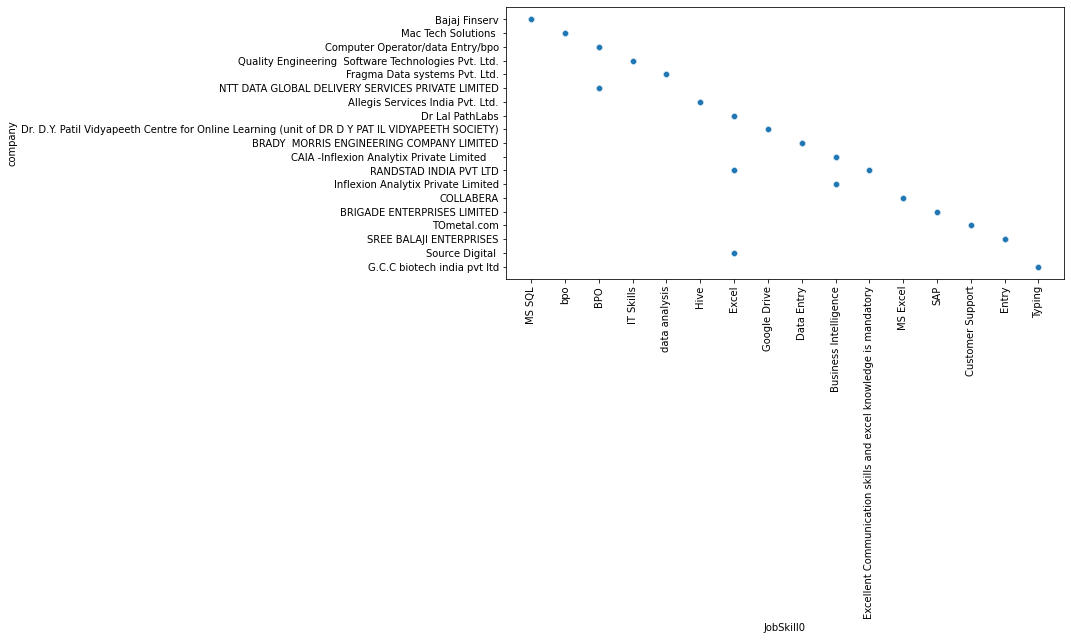

In [27]:
plt.figure(figsize=(10,5))
sns.scatterplot(y=Data1['company'],x=Data1['JobSkill0'])
plt.xticks(rotation=90)
plt.show()

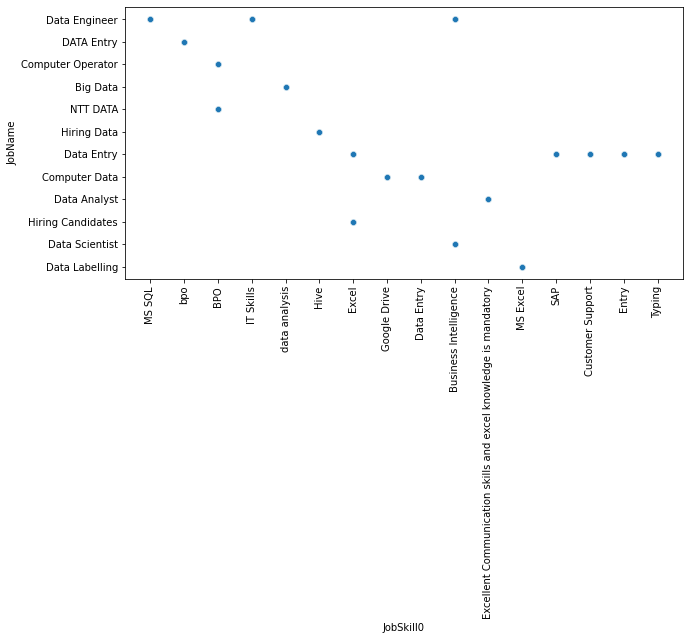

In [28]:
plt.figure(figsize=(10,5))
sns.scatterplot(y=Data1['JobName'],x=Data1['JobSkill0'])
plt.xticks(rotation=90)
plt.show()

In [29]:
Data1.head(2)

,JobName,JobContent,company,LastUpdate,MinExprience,MaxExprience,MinPay,MaxPay,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN


In [30]:
#Remove inside the Bracket value.
Data1['Location0'] = Data1['Location0'].str.replace(r"\(.*\)","")

C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


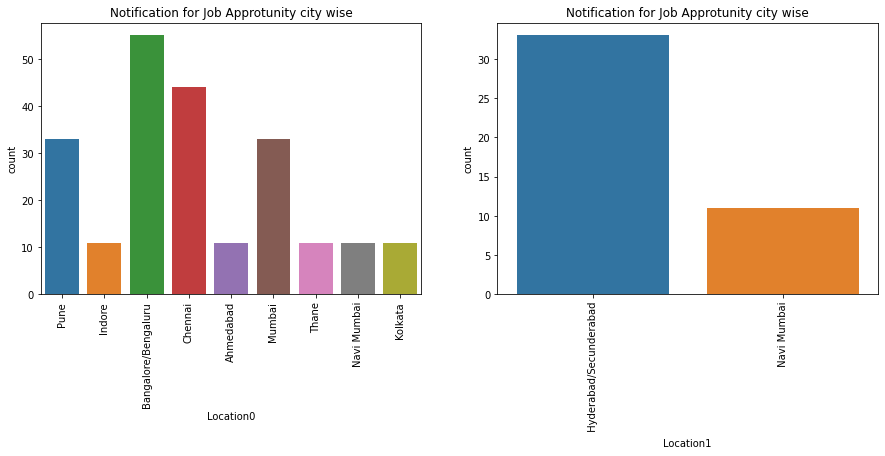

In [31]:
plt.figure(figsize=(15,5))
plt.subplot(121)
sns.countplot(Data1.Location0)
plt.title("Notification for Job Approtunity city wise")
plt.xticks(rotation=90)
plt.subplot(122)
sns.countplot(Data1.Location1)
plt.title("Notification for Job Approtunity city wise")
plt.xticks(rotation=90)
plt.show()

# Observation:
        1.I found, then some similar city names but due to the position of some brackets it is appearing in another or different city so now I think we should remove them
        2.Max. count, Aprrox 40+ of vacancies in the Banglore & chennai and also second perferred location is Hyderabad. Means is that most of the vacancies in the South region with differnt-2 Job Name.

In [32]:
Data1.head(2)

,JobName,JobContent,company,LastUpdate,MinExprience,MaxExprience,MinPay,MaxPay,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN


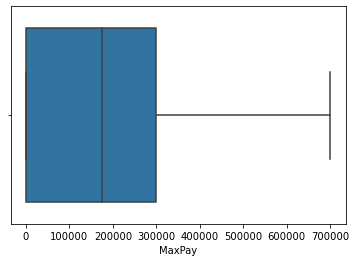

In [61]:
sns.boxplot(data=Data1,x='MaxPay')
plt.show()

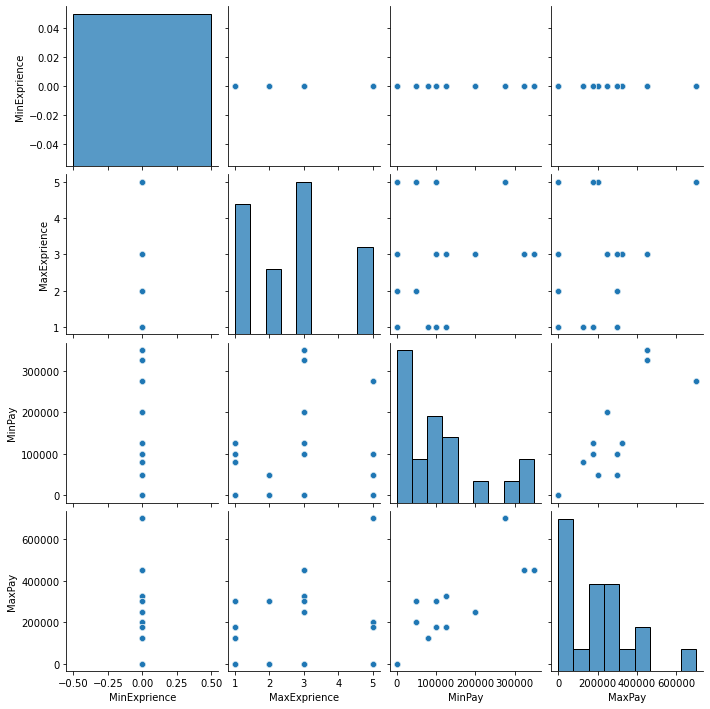

In [33]:
sns.pairplot(Data1)
plt.show()

In [34]:
Data1.corr()

,MinExprience,MaxExprience,MinPay,MaxPay
MinExprience,NaN,NaN,NaN,NaN
MaxExprience,NaN,1.000000,0.209673,0.311861
MinPay,NaN,0.209673,1.000000,0.863104
MaxPay,NaN,0.311861,0.863104,1.000000


In [35]:
Data1.head()

,JobName,JobContent,company,LastUpdate,MinExprience,MaxExprience,MinPay,MaxPay,JobSkill0,JobSkill1,JobSkill2,JobSkill3,JobSkill4,JobSkill5,JobSkill6,JobSkill7,Location0,Location1,Location2,Location3,Location4
0,Data Engineer,Data Engineer,Bajaj Finserv,7 Days Ago,0,3,0,0,MS SQL,Data modeling,Schema,SSIS,Business solutions,Cosmos,Data warehousing,SQL,Pune,NaN,NaN,NaN,NaN
1,DATA Entry,DATA Entry/Computer Operator/WORK FROM Home/Fr...,Mac Tech Solutions,HOT JOB,0,5,275000,700000,bpo,self employed,cce,Non Voice Process,computer operator,Computer Operating,customer care,Non Voice,Indore,Hyderabad/Secunderabad,Bangalore/Bengaluru,NaN,NaN
2,Computer Operator,Computer Operator/Data Entry/Bpo,Computer Operator/data Entry/bpo,HOT JOB,0,3,125000,325000,BPO,data entry,Customer Service,Word,MNC,Computer Operating,Data Maintenance,Voice Process,Pune,NaN,NaN,NaN,NaN
3,Data Engineer,Data Engineer,Quality Engineering Software Technologies Pvt...,13 Days Ago,0,2,0,0,IT Skills,Python,Cloud,Big Data,AWS,Tableau,Power BI,Computer science,Bangalore/Bengaluru,NaN,NaN,NaN,NaN
4,Big Data,Big Data Engineer - Internship with Job Offer,Fragma Data systems Pvt. Ltd.,HOT JOB,0,1,0,0,data analysis,SQL DBs,Analytical,Big Data programming,Spark SQL,Pyspark,Dataframe core,IT Skills,Bangalore/Bengaluru,NaN,NaN,NaN,NaN


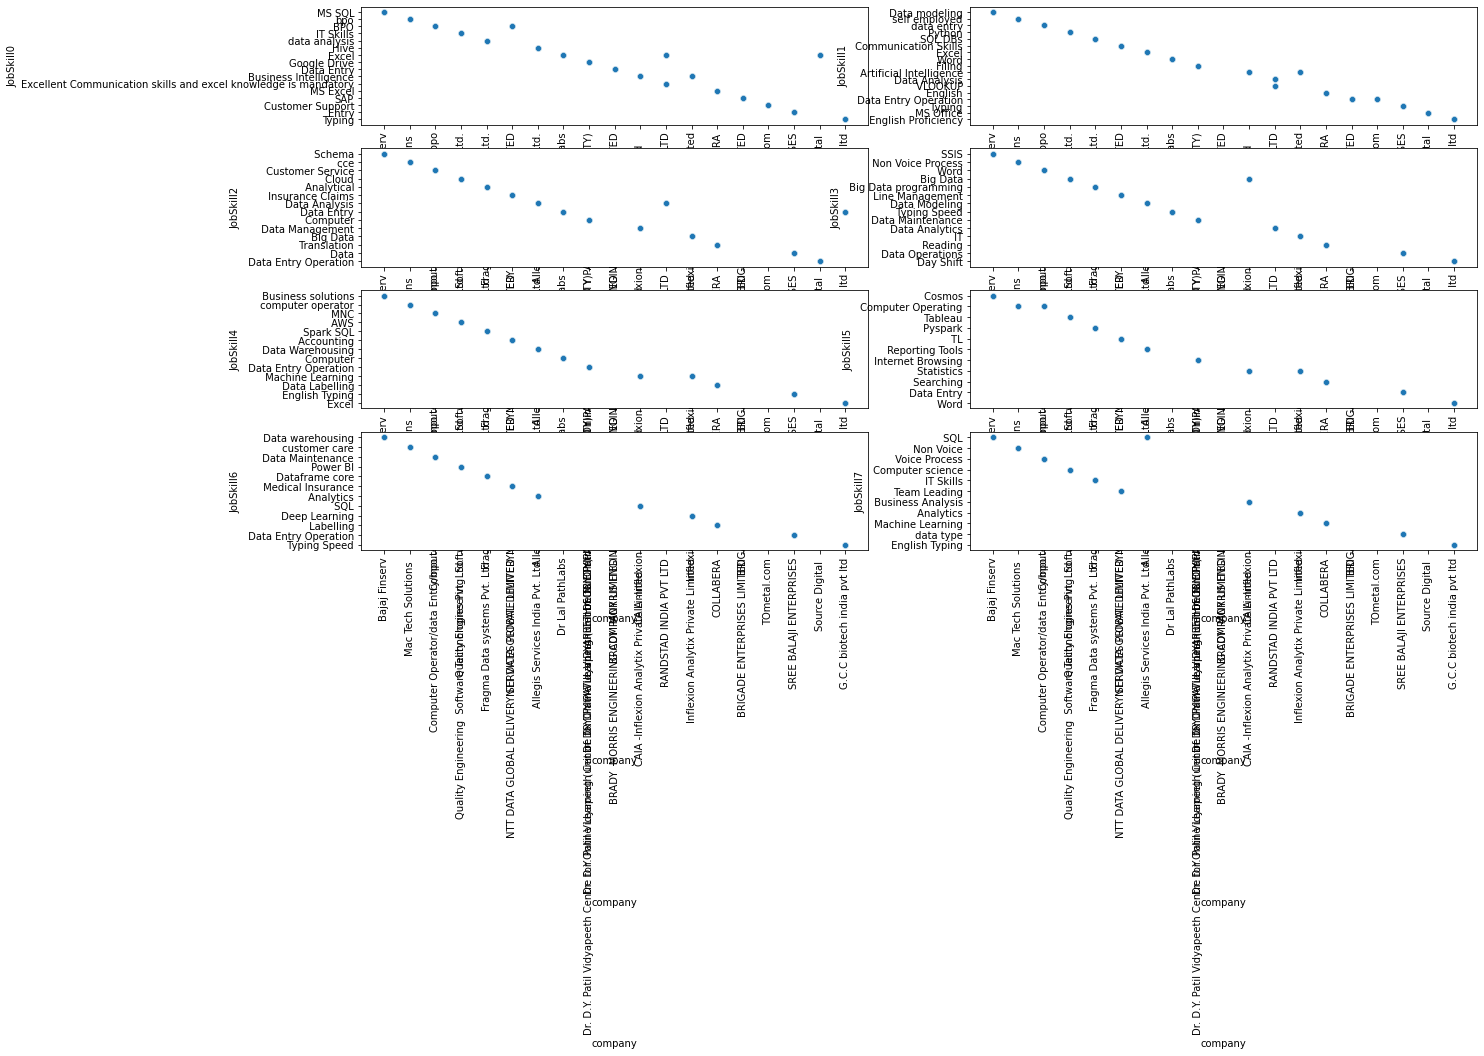

In [48]:
plt.figure(figsize=(20,10))
plt.subplot(421)
sns.scatterplot(data=Data1,x='company',y='JobSkill0',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(422)
sns.scatterplot(data=Data1,x='company',y='JobSkill1',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(423)
sns.scatterplot(data=Data1,x='company',y='JobSkill2',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(424)
sns.scatterplot(data=Data1,x='company',y='JobSkill3',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(425)
sns.scatterplot(data=Data1,x='company',y='JobSkill4',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(426)
sns.scatterplot(data=Data1,x='company',y='JobSkill5',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(427)
sns.scatterplot(data=Data1,x='company',y='JobSkill6',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(428)
sns.scatterplot(data=Data1,x='company',y='JobSkill7',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.show()

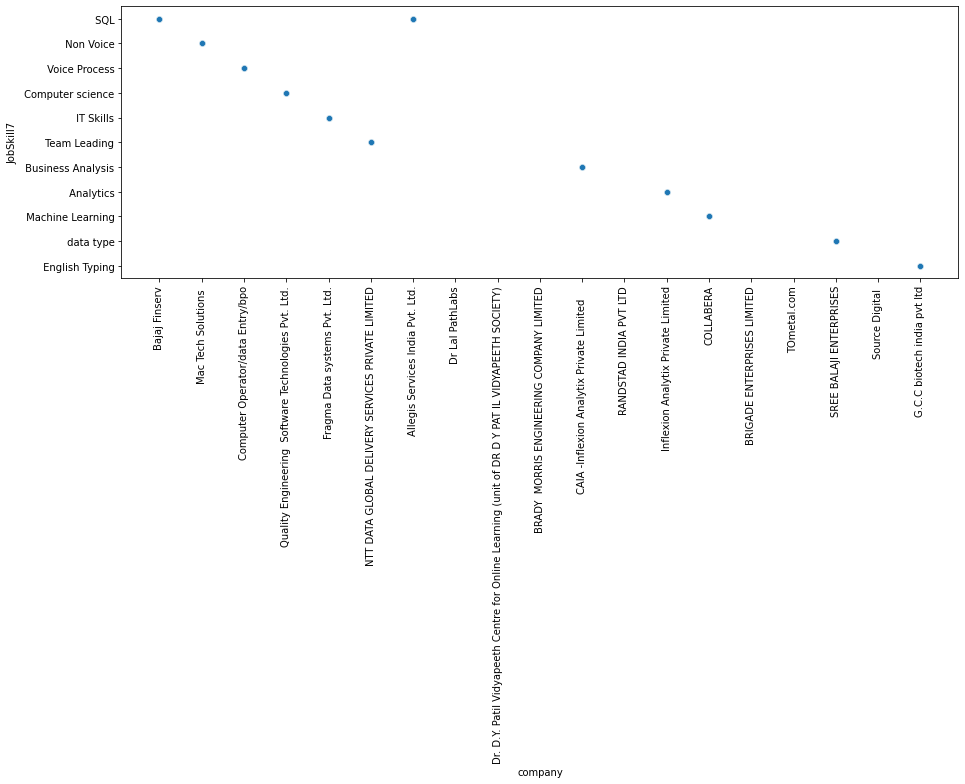

In [43]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=Data1,x='company',y='JobSkill7',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.show()

In [63]:
print(Data1.Location0.isna().sum(),Data1.Location1.isna().sum(),Data1.Location2.isna().sum(),Data1.Location3.isna().sum(),Data1.Location4.isna().sum())

0 176 187 198 198


In [64]:
for i in range(5):
    Data1['Location'+str(i)+''] = Data1['Location'+str(i)+''].fillna('0') 

In [65]:
print(Data1.Location0.isna().sum(),Data1.Location1.isna().sum(),Data1.Location2.isna().sum(),Data1.Location3.isna().sum(),Data1.Location4.isna().sum())

0 0 0 0 0


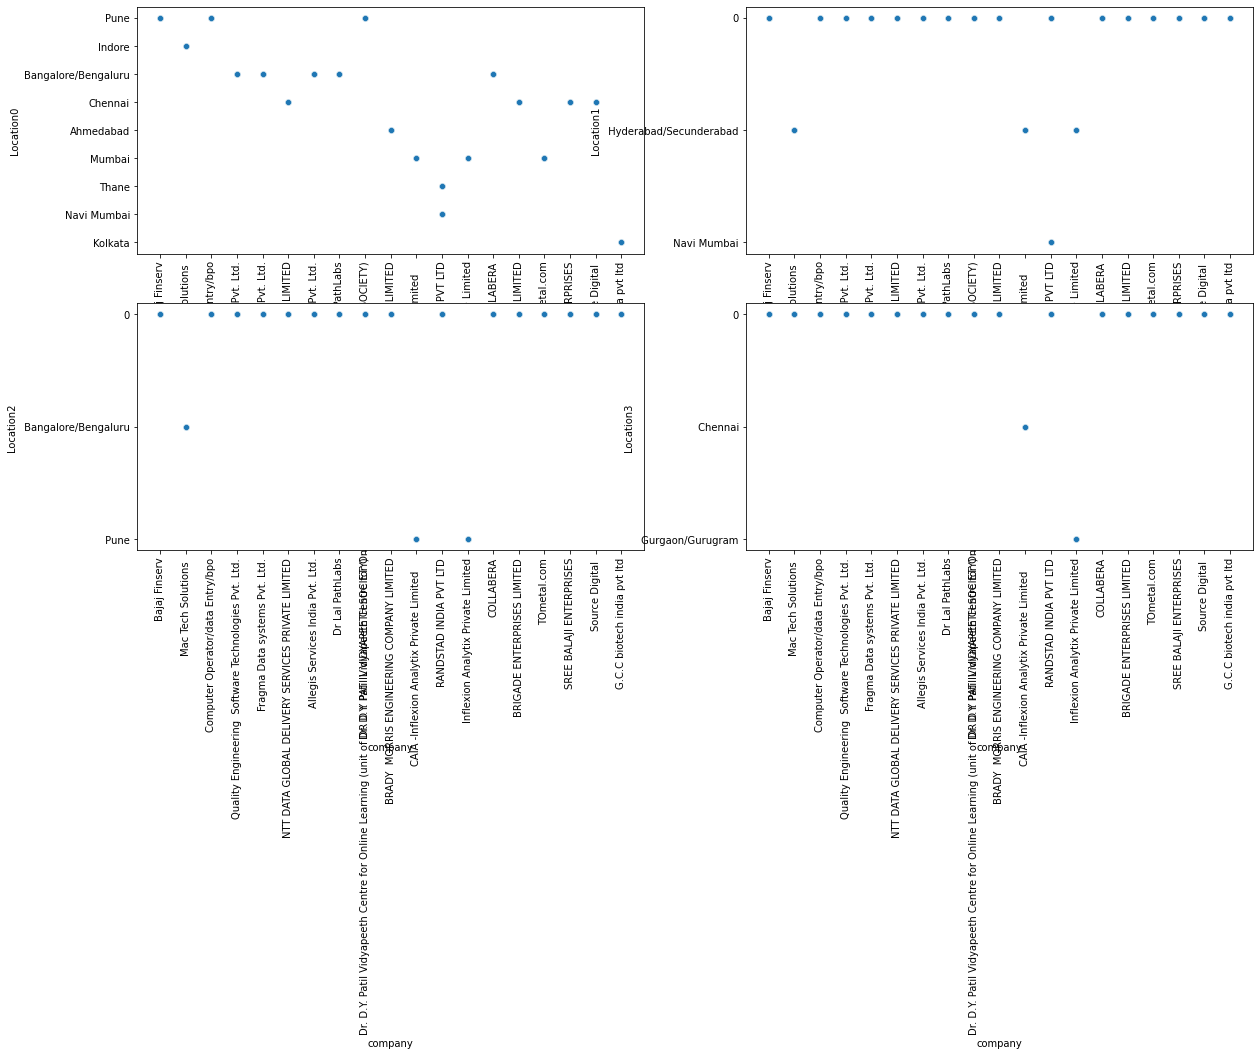

In [66]:
plt.figure(figsize=(20,10))
plt.subplot(221)
sns.scatterplot(data=Data1,x='company',y='Location0',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(222)
sns.scatterplot(data=Data1,x='company',y='Location1',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(223)
sns.scatterplot(data=Data1,x='company',y='Location2',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.subplot(224)
sns.scatterplot(data=Data1,x='company',y='Location3',legend=False, sizes=(20, 2000))
plt.xticks(rotation=90)
plt.show()

# Overview

# Candidates type the ***Data Keyword.


Positive:
Find total 300 Raw Job Notification, but Maximum count of the job Notification related to the *Data Engineer & *Data Entry for South Region ( Hyderabad, Bangalore, Chennai etc.. ) 
Candidate should have a Max 3 year Experience and these all company hire the Fresher also.
All company mentioned in the job Notification 0-X payable amount (Annum). I think, directly, Company want to tell your job interview will decide how much we will provide the salary per annum.

Negative:
For the Data Entry : Company provide the 0- 7 Lakh package but person should have a 3 Year experience. But for the Data  Scientist 2 Year experience and they will provide 3.5-4.5 Lakh only. 
	*** We have to think about it ... is it real or fake.
